In [1]:
# install the profiling library 
!pip install ydata-profiling --quiet

In [2]:
import matplotlib.pyplot as plt

In [34]:
import pandas as pd
from ydata_profiling import ProfileReport

# load cleaned dataset
df = pd.read_csv("cleaned_data.csv")

# generate the profiling report
profile = ProfileReport(df, title="Solar Flare Data - EDA Overview", explorative=True)
# save the report as an HTML file so you can open it in a browser
profile.to_file("eda_overview_report.html")

print("Report saved as eda_overview_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 22.07it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report saved as eda_overview_report.html


# 1. understanding data manually

In [4]:
# 1. shape 
print("Shape (rows, columns):", df.shape)

 

Shape (rows, columns): (10068, 22)


In [5]:
# 2. columns 
print("Columns:")
print(df.columns.tolist())


Columns:
['Date', 'Radio_Flux_10.7cm', 'SESC_Sunspot_Number', 'Sunspot_Area_10E-6_Hemis', 'New_Regions', 'Flares_C', 'Flares_M', 'Flares_X', 'Flares_S', 'Flares_1', 'Flares_2', 'Flares_3', 'Year', 'Radio_Flux_10.7cm_avg_3d', 'Radio_Flux_10.7cm_avg_7d', 'Radio_Flux_10.7cm_avg_27d', 'SESC_Sunspot_Number_avg_3d', 'SESC_Sunspot_Number_avg_7d', 'SESC_Sunspot_Number_avg_27d', 'Sunspot_Area_10E-6_Hemis_avg_3d', 'Sunspot_Area_10E-6_Hemis_avg_7d', 'Sunspot_Area_10E-6_Hemis_avg_27d']


In [6]:
# 3. date range
df["Date"] = pd.to_datetime(df["Date"])
print("Date range:", df["Date"].min(), "to", df["Date"].max())


Date range: 1999-01-27 00:00:00 to 2026-08-20 00:00:00


In [7]:
# 4. data types 
print("Data types:")
print(df.dtypes)


Data types:
Date                                datetime64[ns]
Radio_Flux_10.7cm                          float64
SESC_Sunspot_Number                          int64
Sunspot_Area_10E-6_Hemis                     int64
New_Regions                                  int64
Flares_C                                   float64
Flares_M                                   float64
Flares_X                                   float64
Flares_S                                     int64
Flares_1                                     int64
Flares_2                                     int64
Flares_3                                     int64
Year                                         int64
Radio_Flux_10.7cm_avg_3d                   float64
Radio_Flux_10.7cm_avg_7d                   float64
Radio_Flux_10.7cm_avg_27d                  float64
SESC_Sunspot_Number_avg_3d                 float64
SESC_Sunspot_Number_avg_7d                 float64
SESC_Sunspot_Number_avg_27d                float64
Sunspot_Area_10E-6_

In [8]:
# 5. remaining missing values - har column mein kitne NaN values bache hain
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
Date                                0
Radio_Flux_10.7cm                   0
SESC_Sunspot_Number                 0
Sunspot_Area_10E-6_Hemis            0
New_Regions                         0
Flares_C                            0
Flares_M                            0
Flares_X                            0
Flares_S                            0
Flares_1                            0
Flares_2                            0
Flares_3                            0
Year                                0
Radio_Flux_10.7cm_avg_3d            0
Radio_Flux_10.7cm_avg_7d            0
Radio_Flux_10.7cm_avg_27d           0
SESC_Sunspot_Number_avg_3d          0
SESC_Sunspot_Number_avg_7d          0
SESC_Sunspot_Number_avg_27d         0
Sunspot_Area_10E-6_Hemis_avg_3d     0
Sunspot_Area_10E-6_Hemis_avg_7d     0
Sunspot_Area_10E-6_Hemis_avg_27d    0
dtype: int64


# 2.Understanding each feature

In [9]:
# raw (original) columns
raw_columns = [
    "Radio_Flux_10.7cm",
    "SESC_Sunspot_Number",
    "Sunspot_Area_10E-6_Hemis",
    "New_Regions",
]
# rolling average columns (3-day, 7-day, 27-day)
rolling_columns = [
    "Radio_Flux_10.7cm_avg_3d", "Radio_Flux_10.7cm_avg_7d", "Radio_Flux_10.7cm_avg_27d",
    "SESC_Sunspot_Number_avg_3d", "SESC_Sunspot_Number_avg_7d", "SESC_Sunspot_Number_avg_27d",
    "Sunspot_Area_10E-6_Hemis_avg_3d", "Sunspot_Area_10E-6_Hemis_avg_7d", "Sunspot_Area_10E-6_Hemis_avg_27d",
]
# flare count columns (C, M, X) 
flare_columns = ["Flares_C", "Flares_M", "Flares_X"]
all_columns = raw_columns + rolling_columns

# Quick summary statistics for every column
# (mean, min, max, std, etc. )
print("Summary statistics (raw + rolling columns):")
print(df[all_columns].describe())
print()

print("Summary statistics (flare counts - C, M, X):")
print(df[flare_columns].describe())
print()

Summary statistics (raw + rolling columns):
       Radio_Flux_10.7cm  SESC_Sunspot_Number  Sunspot_Area_10E-6_Hemis  \
count       10068.000000         10068.000000              10068.000000   
mean          115.244338            73.548470                511.045888   
std            44.723086            66.665882                576.379466   
min            64.000000             0.000000                  0.000000   
25%            75.000000            14.000000                 40.000000   
50%           104.000000            59.000000                330.000000   
75%           145.000000           118.000000                785.000000   
max           336.000000           401.000000               5690.000000   

        New_Regions  Radio_Flux_10.7cm_avg_3d  Radio_Flux_10.7cm_avg_7d  \
count  10068.000000              10068.000000              10068.000000   
mean       0.601212                115.245266                115.251972   
std        0.884839                 44.498608          

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

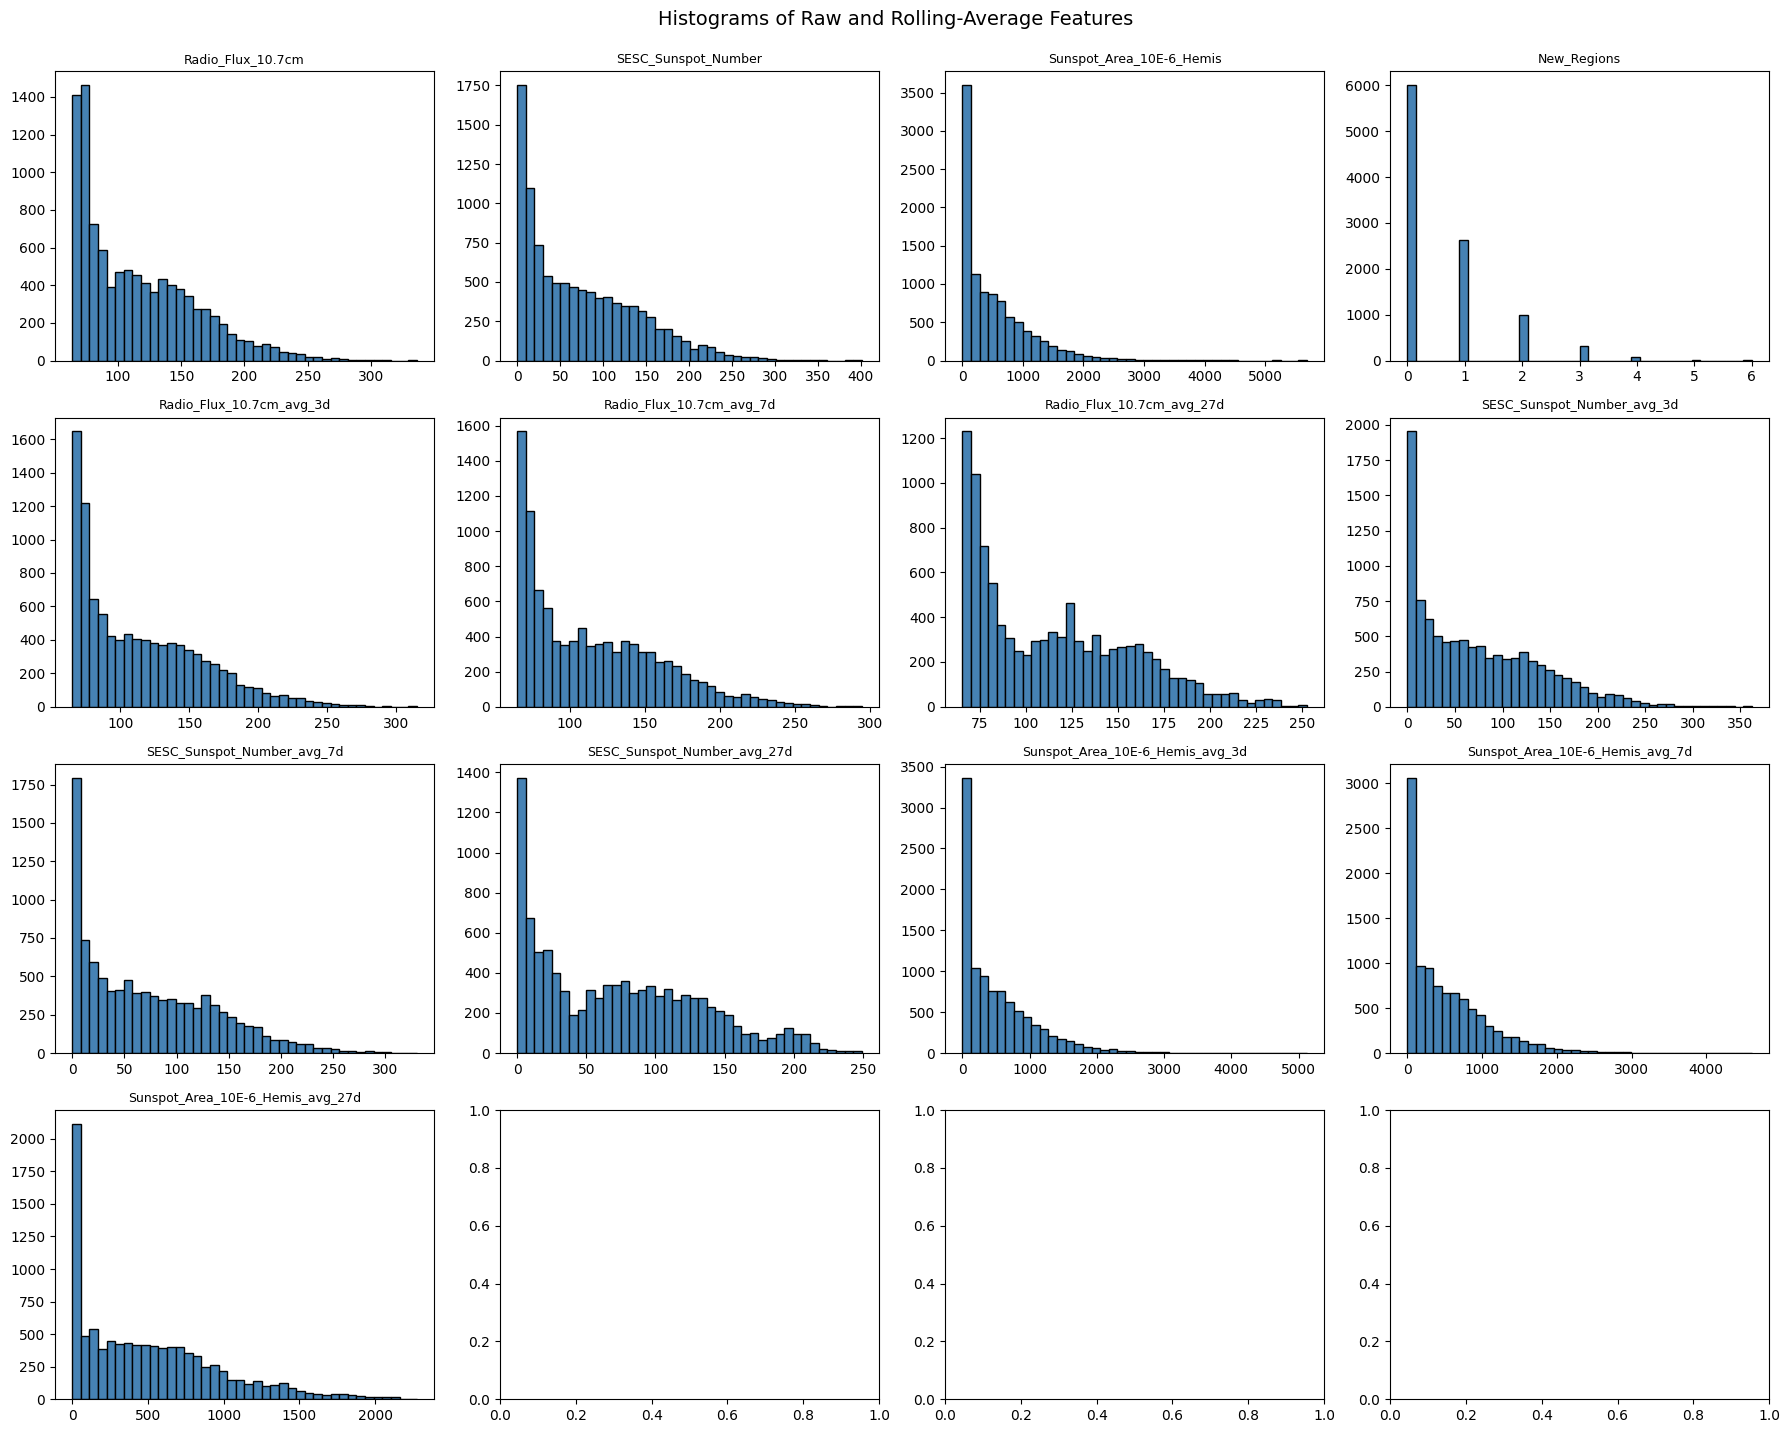

In [11]:
#histogram
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()  # 2D grid ko ek simple list bana diya, loop karna aasan ho jaye
 
for i, col in enumerate(all_columns):
    axes[i].hist(df[col], bins=40, color="steelblue", edgecolor="black")
    axes[i].set_title(col, fontsize=9)
 
plt.tight_layout()
plt.suptitle("Histograms of Raw and Rolling-Average Features", y=1.02, fontsize=14)
plt.savefig("histograms_all_features.png", bbox_inches="tight")
plt.show()

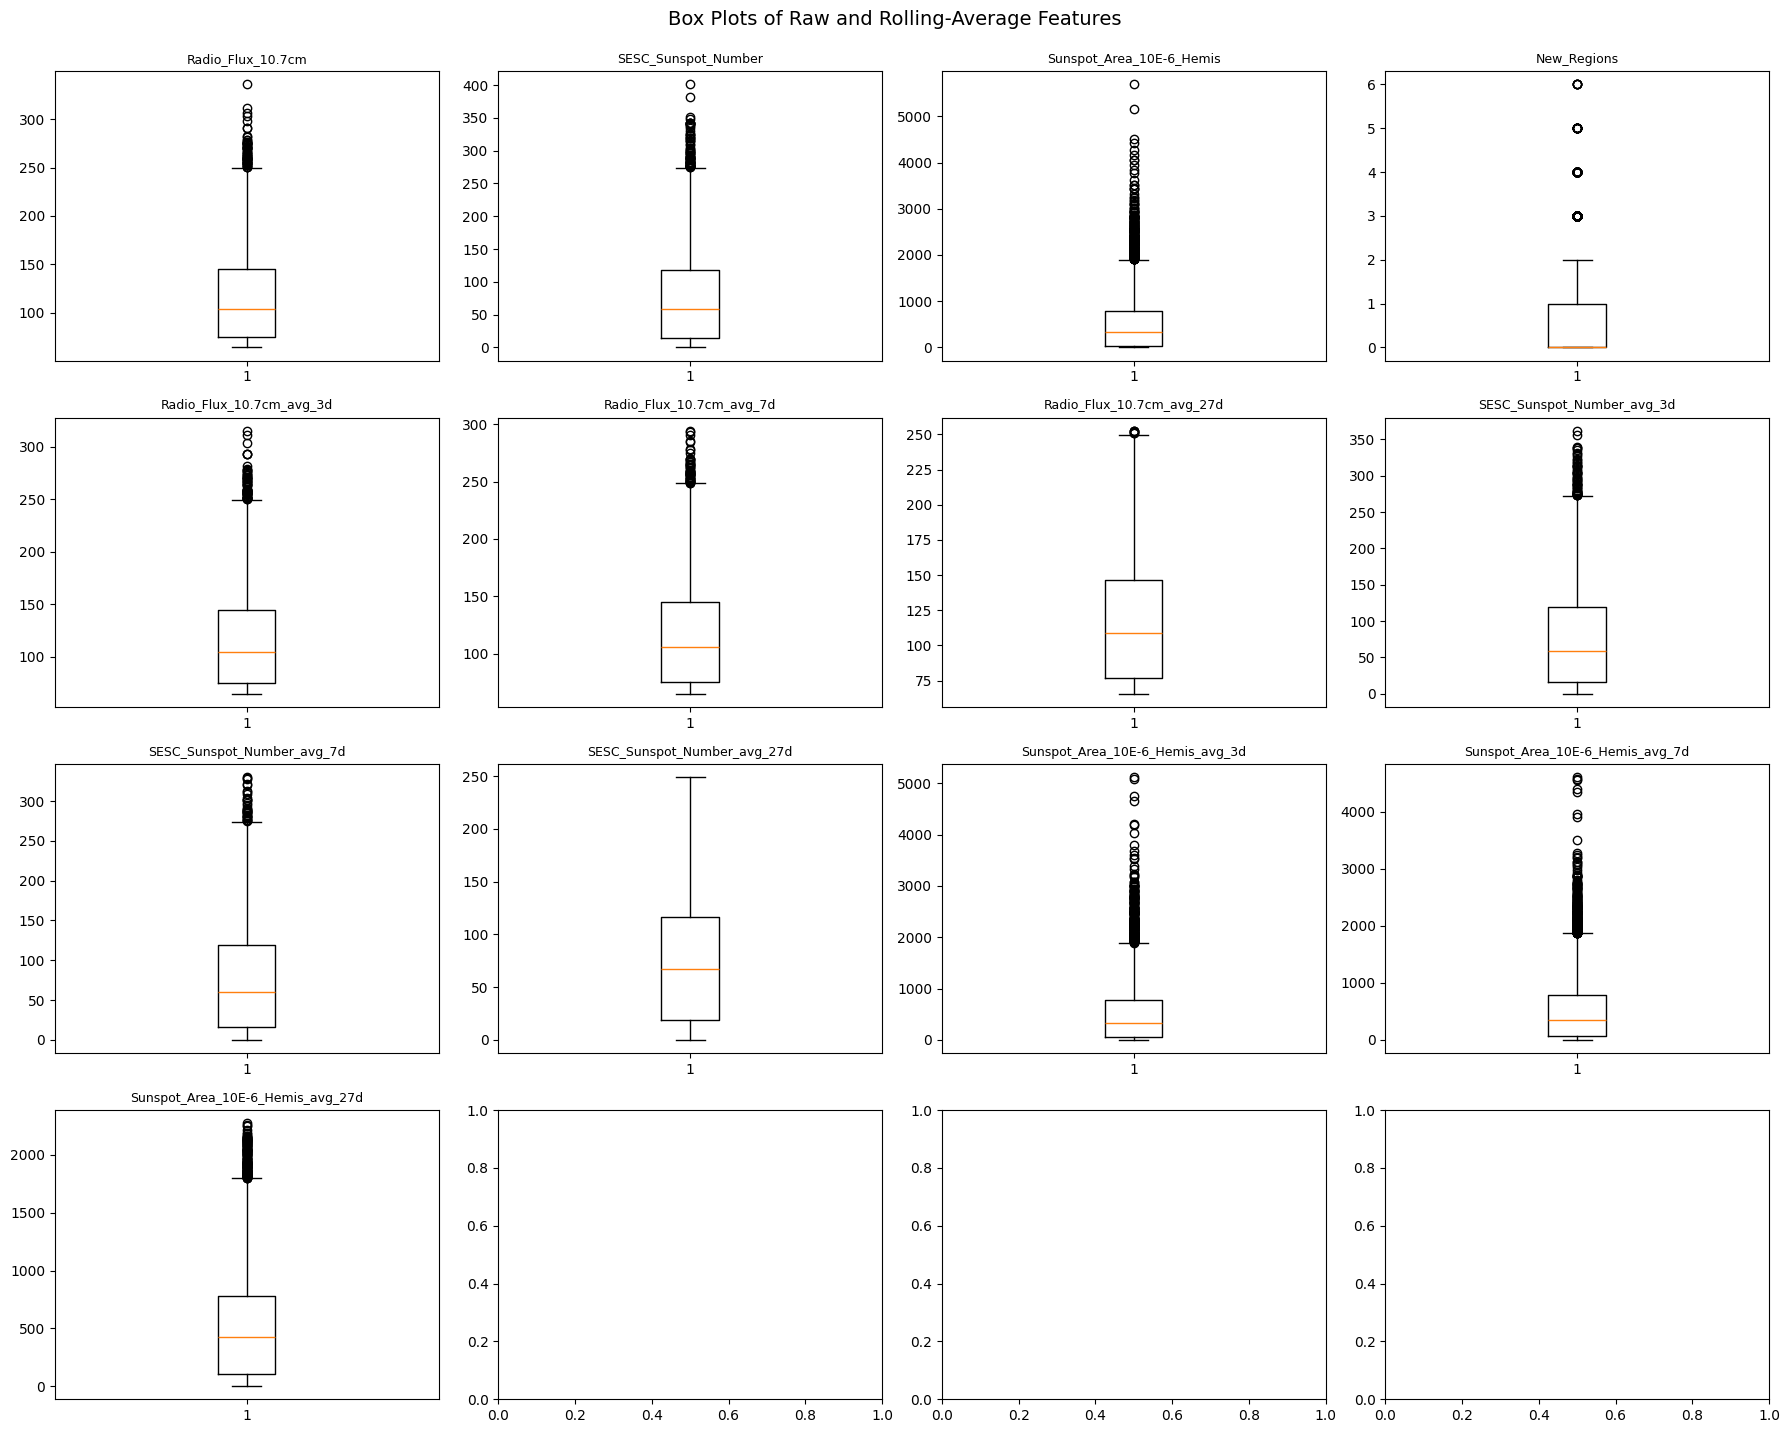

In [12]:
#  Box plots 
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
 
for i, col in enumerate(all_columns):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col, fontsize=9)
 
plt.tight_layout()
plt.suptitle("Box Plots of Raw and Rolling-Average Features", y=1.02, fontsize=14)
plt.savefig("boxplots_all_features.png", bbox_inches="tight")
plt.show()

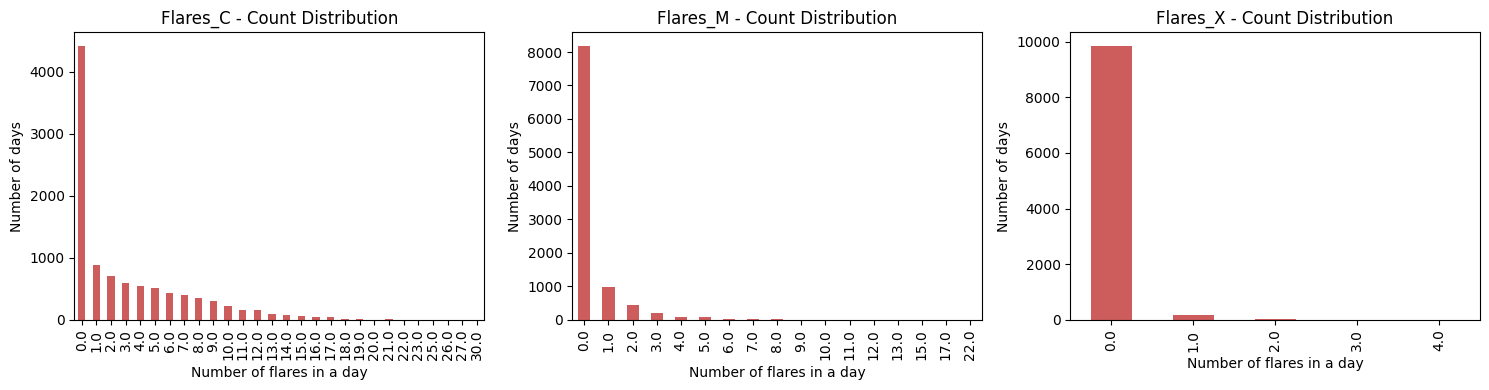

In [13]:
# Flare counts (C, M, X) 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
for i, col in enumerate(flare_columns):
    df[col].value_counts().sort_index().plot(kind="bar", ax=axes[i], color="indianred")
    axes[i].set_title(f"{col} - Count Distribution")
    axes[i].set_xlabel("Number of flares in a day")
    axes[i].set_ylabel("Number of days")
 
plt.tight_layout()
plt.savefig("flare_count_distributions.png", bbox_inches="tight")
plt.show()

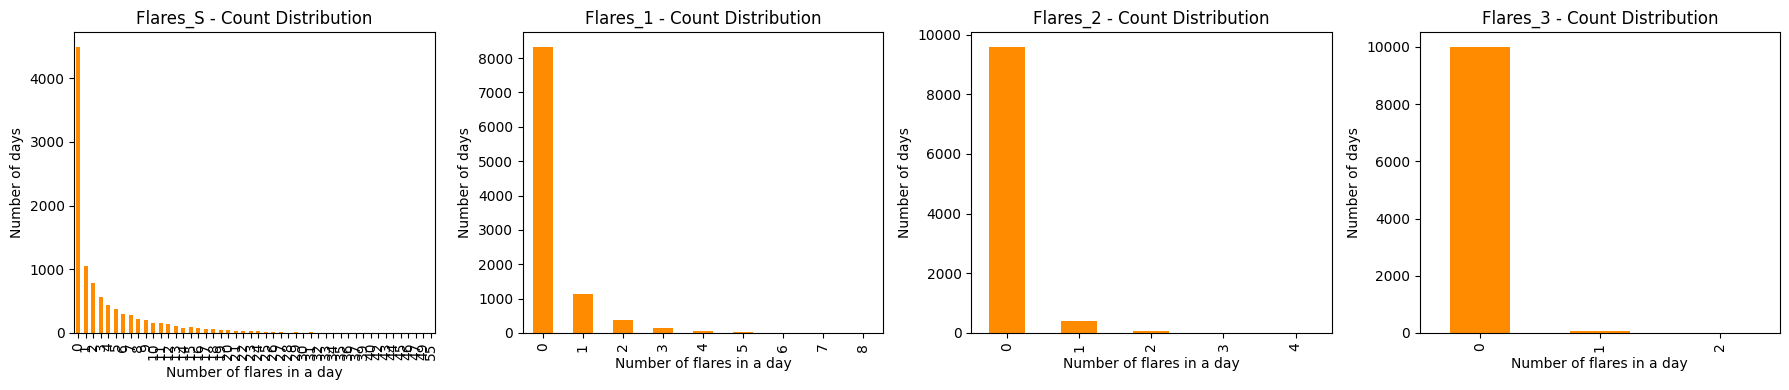

All plots saved: histograms_all_features.png, boxplots_all_features.png, flare_count_distributions.png, optical_flare_count_distributions.png


In [14]:
#Optical flare counts (S, 1, 2, 3)
optical_columns = ["Flares_S", "Flares_1", "Flares_2", "Flares_3"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
 
for i, col in enumerate(optical_columns):
    df[col].value_counts().sort_index().plot(kind="bar", ax=axes[i], color="darkorange")
    axes[i].set_title(f"{col} - Count Distribution")
    axes[i].set_xlabel("Number of flares in a day")
    axes[i].set_ylabel("Number of days")
 
plt.tight_layout()
plt.savefig("optical_flare_count_distributions.png", bbox_inches="tight")
plt.show()
 
print("All plots saved: histograms_all_features.png, boxplots_all_features.png, "
      "flare_count_distributions.png, optical_flare_count_distributions.png")

# 3. checking distributions 

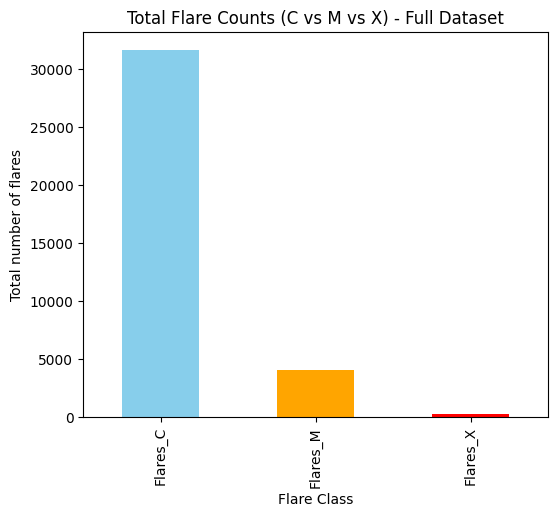

In [15]:
#  Bar chart
flare_totals = df[["Flares_C", "Flares_M", "Flares_X"]].sum()
 
plt.figure(figsize=(6, 5))
flare_totals.plot(kind="bar", color=["skyblue", "orange", "red"])
plt.title("Total Flare Counts (C vs M vs X) - Full Dataset")
plt.ylabel("Total number of flares")
plt.xlabel("Flare Class")
plt.savefig("step3_total_flare_counts.png", bbox_inches="tight")
plt.show()

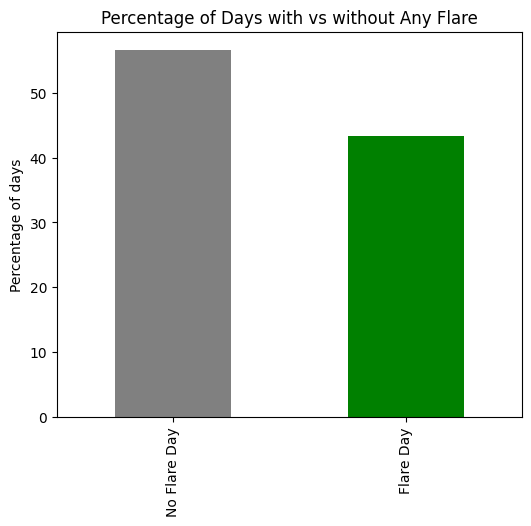

In [16]:
# bar chart: "Zero flare days" vs "Flare days" ka %

df["any_flare_day"] = ((df["Flares_C"] + df["Flares_M"] + df["Flares_X"]) > 0).astype(int)
 
flare_day_pct = df["any_flare_day"].value_counts(normalize=True) * 100
flare_day_pct.index = ["No Flare Day", "Flare Day"]  # 0 aur 1 ko readable label diya
 
plt.figure(figsize=(6, 5))
flare_day_pct.plot(kind="bar", color=["gray", "green"])
plt.title("Percentage of Days with vs without Any Flare")
plt.ylabel("Percentage of days")
plt.savefig("step3_flare_vs_noflare_days.png", bbox_inches="tight")
plt.show()

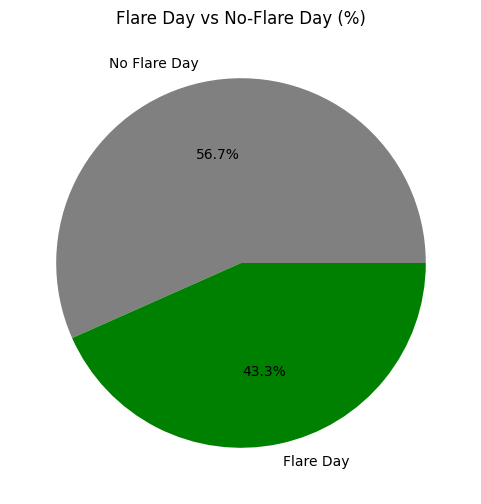

In [17]:
# pie chart "Zero flare days" vs "Flare days" ka %
plt.figure(figsize=(6, 6))
plt.pie(flare_day_pct, labels=flare_day_pct.index, autopct="%1.1f%%",
        colors=["gray", "green"])
plt.title("Flare Day vs No-Flare Day (%)")
plt.savefig("step3_flare_vs_noflare_pie.png", bbox_inches="tight")
plt.show()

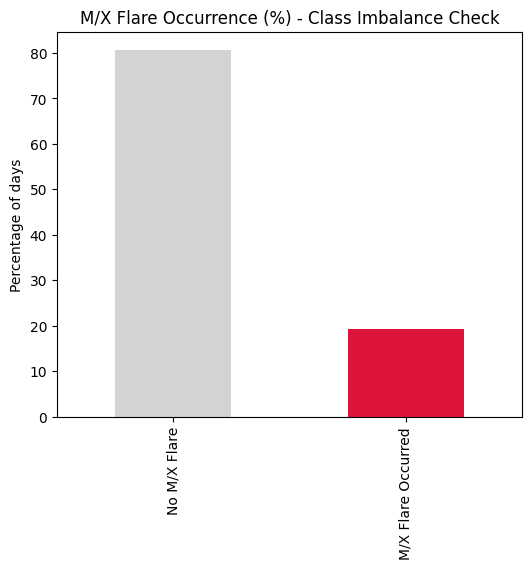

M/X flare occurred on 19.37 % of days
No M/X flare on 80.63 % of days


In [18]:
#  M/X occurrence % 
df["mx_occurred"] = ((df["Flares_M"] + df["Flares_X"]) > 0).astype(int)
 
mx_pct = df["mx_occurred"].value_counts(normalize=True) * 100
mx_pct.index = ["No M/X Flare", "M/X Flare Occurred"]
 
plt.figure(figsize=(6, 5))
mx_pct.plot(kind="bar", color=["lightgray", "crimson"])
plt.title("M/X Flare Occurrence (%) - Class Imbalance Check")
plt.ylabel("Percentage of days")
plt.savefig("step3_mx_occurrence_imbalance.png", bbox_inches="tight")
plt.show()
 
print("M/X flare occurred on", round(mx_pct["M/X Flare Occurred"], 2), "% of days")
print("No M/X flare on", round(mx_pct["No M/X Flare"], 2), "% of days")

# 4. time based analysis

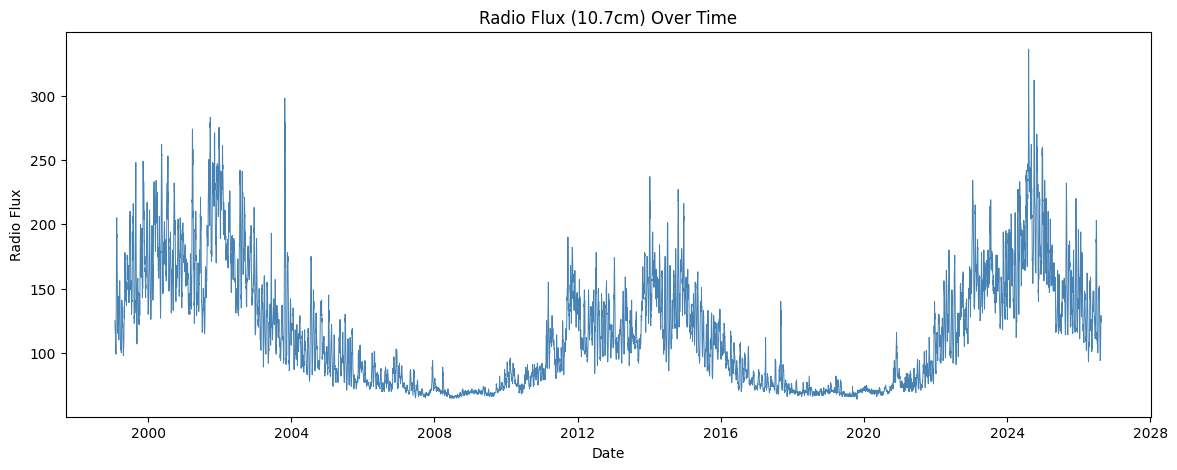

In [19]:
# Line plot: Radio Flux vs Time
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Radio_Flux_10.7cm"], color="steelblue", linewidth=0.7)
plt.title("Radio Flux (10.7cm) Over Time")
plt.xlabel("Date")
plt.ylabel("Radio Flux")
plt.savefig("step4_radio_flux_over_time.png", bbox_inches="tight")
plt.show()

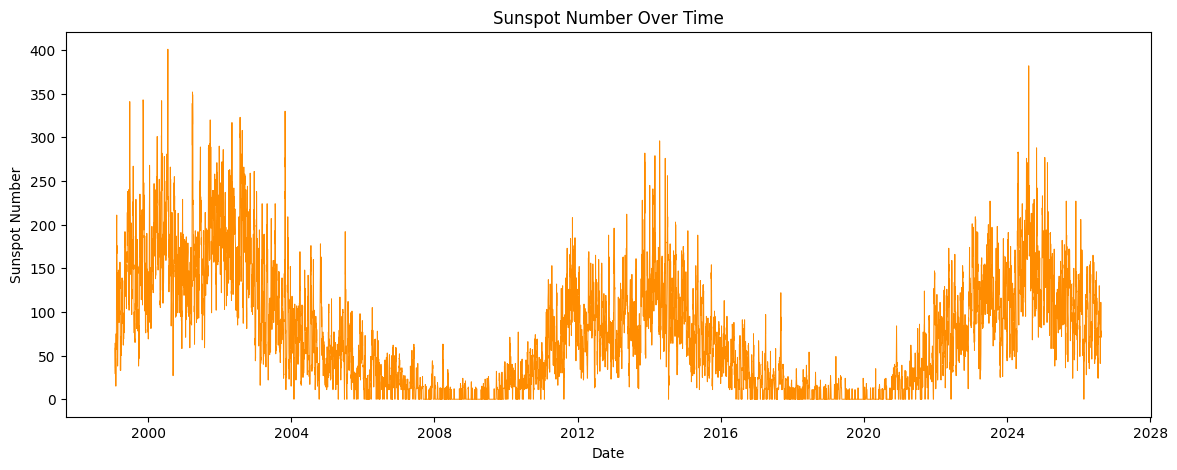

In [20]:
# Line plot: Sunspot Number vs Time
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["SESC_Sunspot_Number"], color="darkorange", linewidth=0.7)
plt.title("Sunspot Number Over Time")
plt.xlabel("Date")
plt.ylabel("Sunspot Number")
plt.savefig("step4_sunspot_number_over_time.png", bbox_inches="tight")
plt.show()

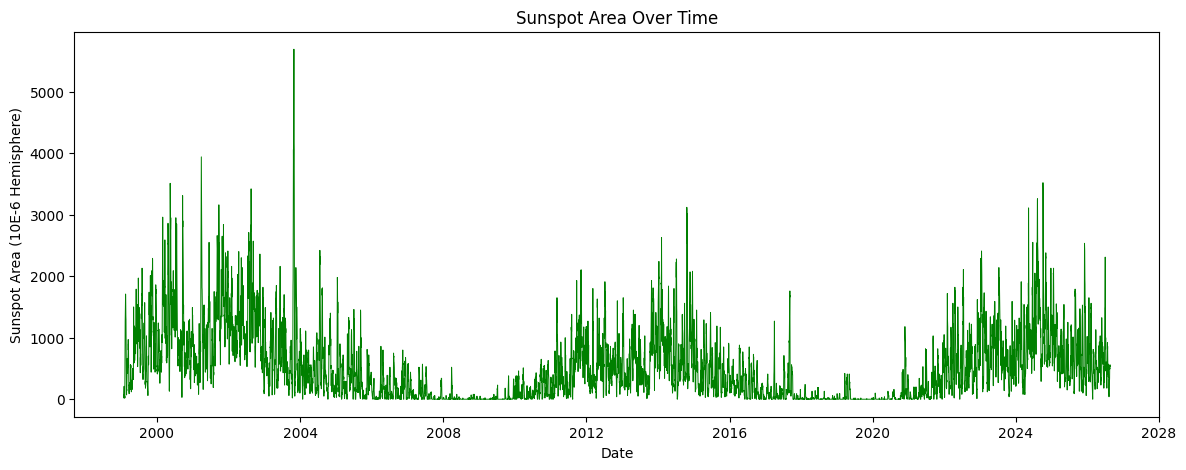

In [21]:
#  Line plot: Sunspot Area vs Time
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Sunspot_Area_10E-6_Hemis"], color="green", linewidth=0.7)
plt.title("Sunspot Area Over Time")
plt.xlabel("Date")
plt.ylabel("Sunspot Area (10E-6 Hemisphere)")
plt.savefig("step4_sunspot_area_over_time.png", bbox_inches="tight")
plt.show()

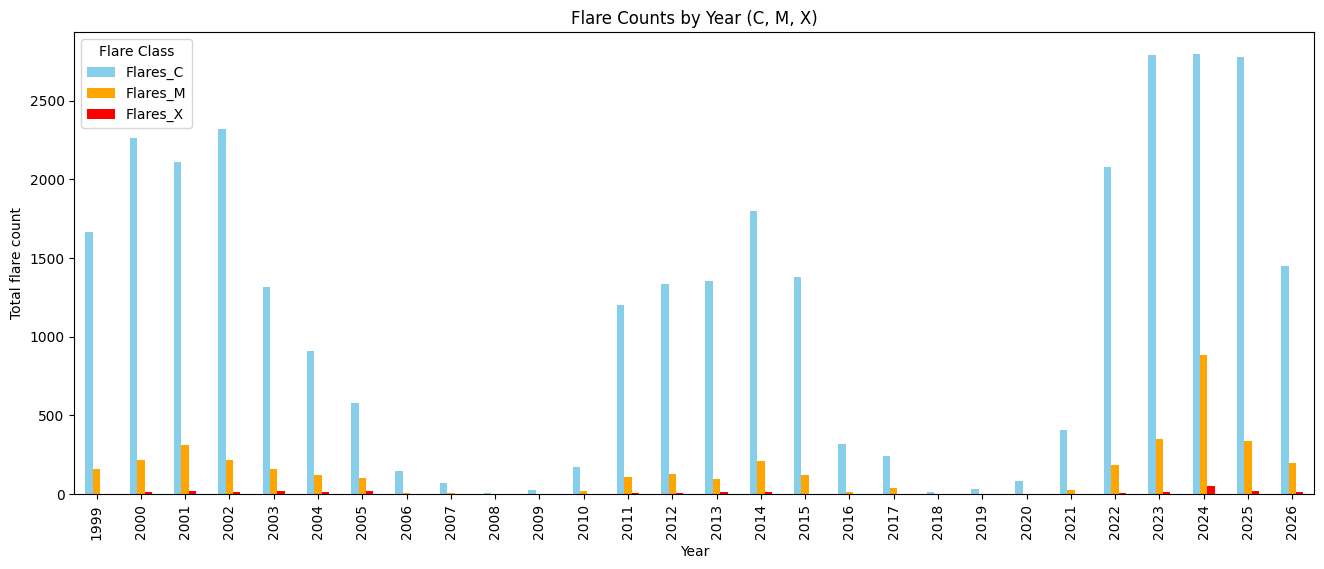

In [22]:
 #Bar chart: Flare counts (C, M, X) by Year
yearly_flares = df.groupby("Year")[["Flares_C", "Flares_M", "Flares_X"]].sum()
yearly_flares.plot(kind="bar", figsize=(16, 6), color=["skyblue", "orange", "red"])
plt.title("Flare Counts by Year (C, M, X)")
plt.xlabel("Year")
plt.ylabel("Total flare count")
plt.legend(title="Flare Class")
plt.savefig("step4_flare_counts_by_year.png", bbox_inches="tight")
plt.show()

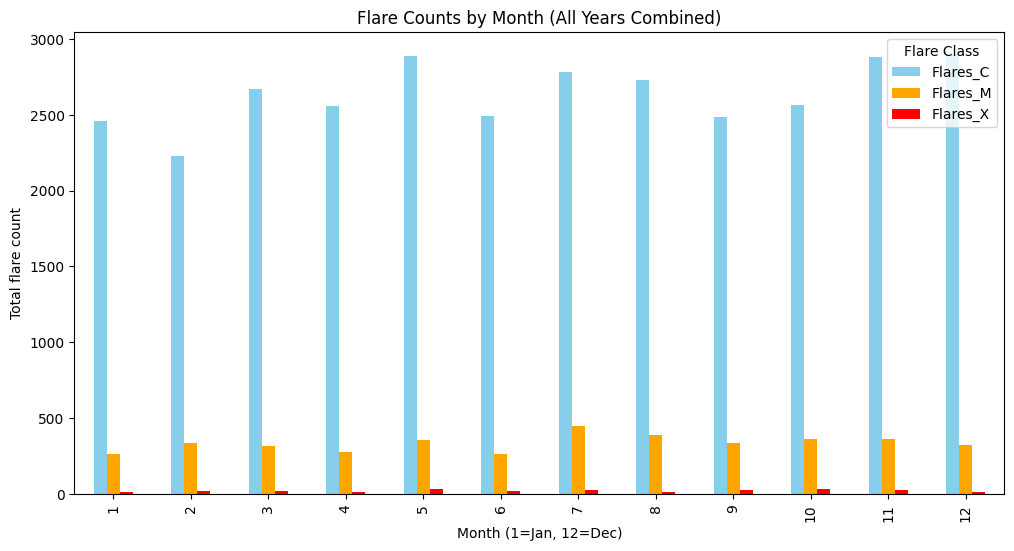

In [23]:
#Bar chart: Flare counts by Month (seasonality check)
df["Month"] = df["Date"].dt.month
 
monthly_flares = df.groupby("Month")[["Flares_C", "Flares_M", "Flares_X"]].sum()
 
monthly_flares.plot(kind="bar", figsize=(12, 6), color=["skyblue", "orange", "red"])
plt.title("Flare Counts by Month (All Years Combined)")
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.ylabel("Total flare count")
plt.legend(title="Flare Class")
plt.savefig("step4_flare_counts_by_month.png", bbox_inches="tight")
plt.show()
 


#  Relationship Analysis (Bivariate)

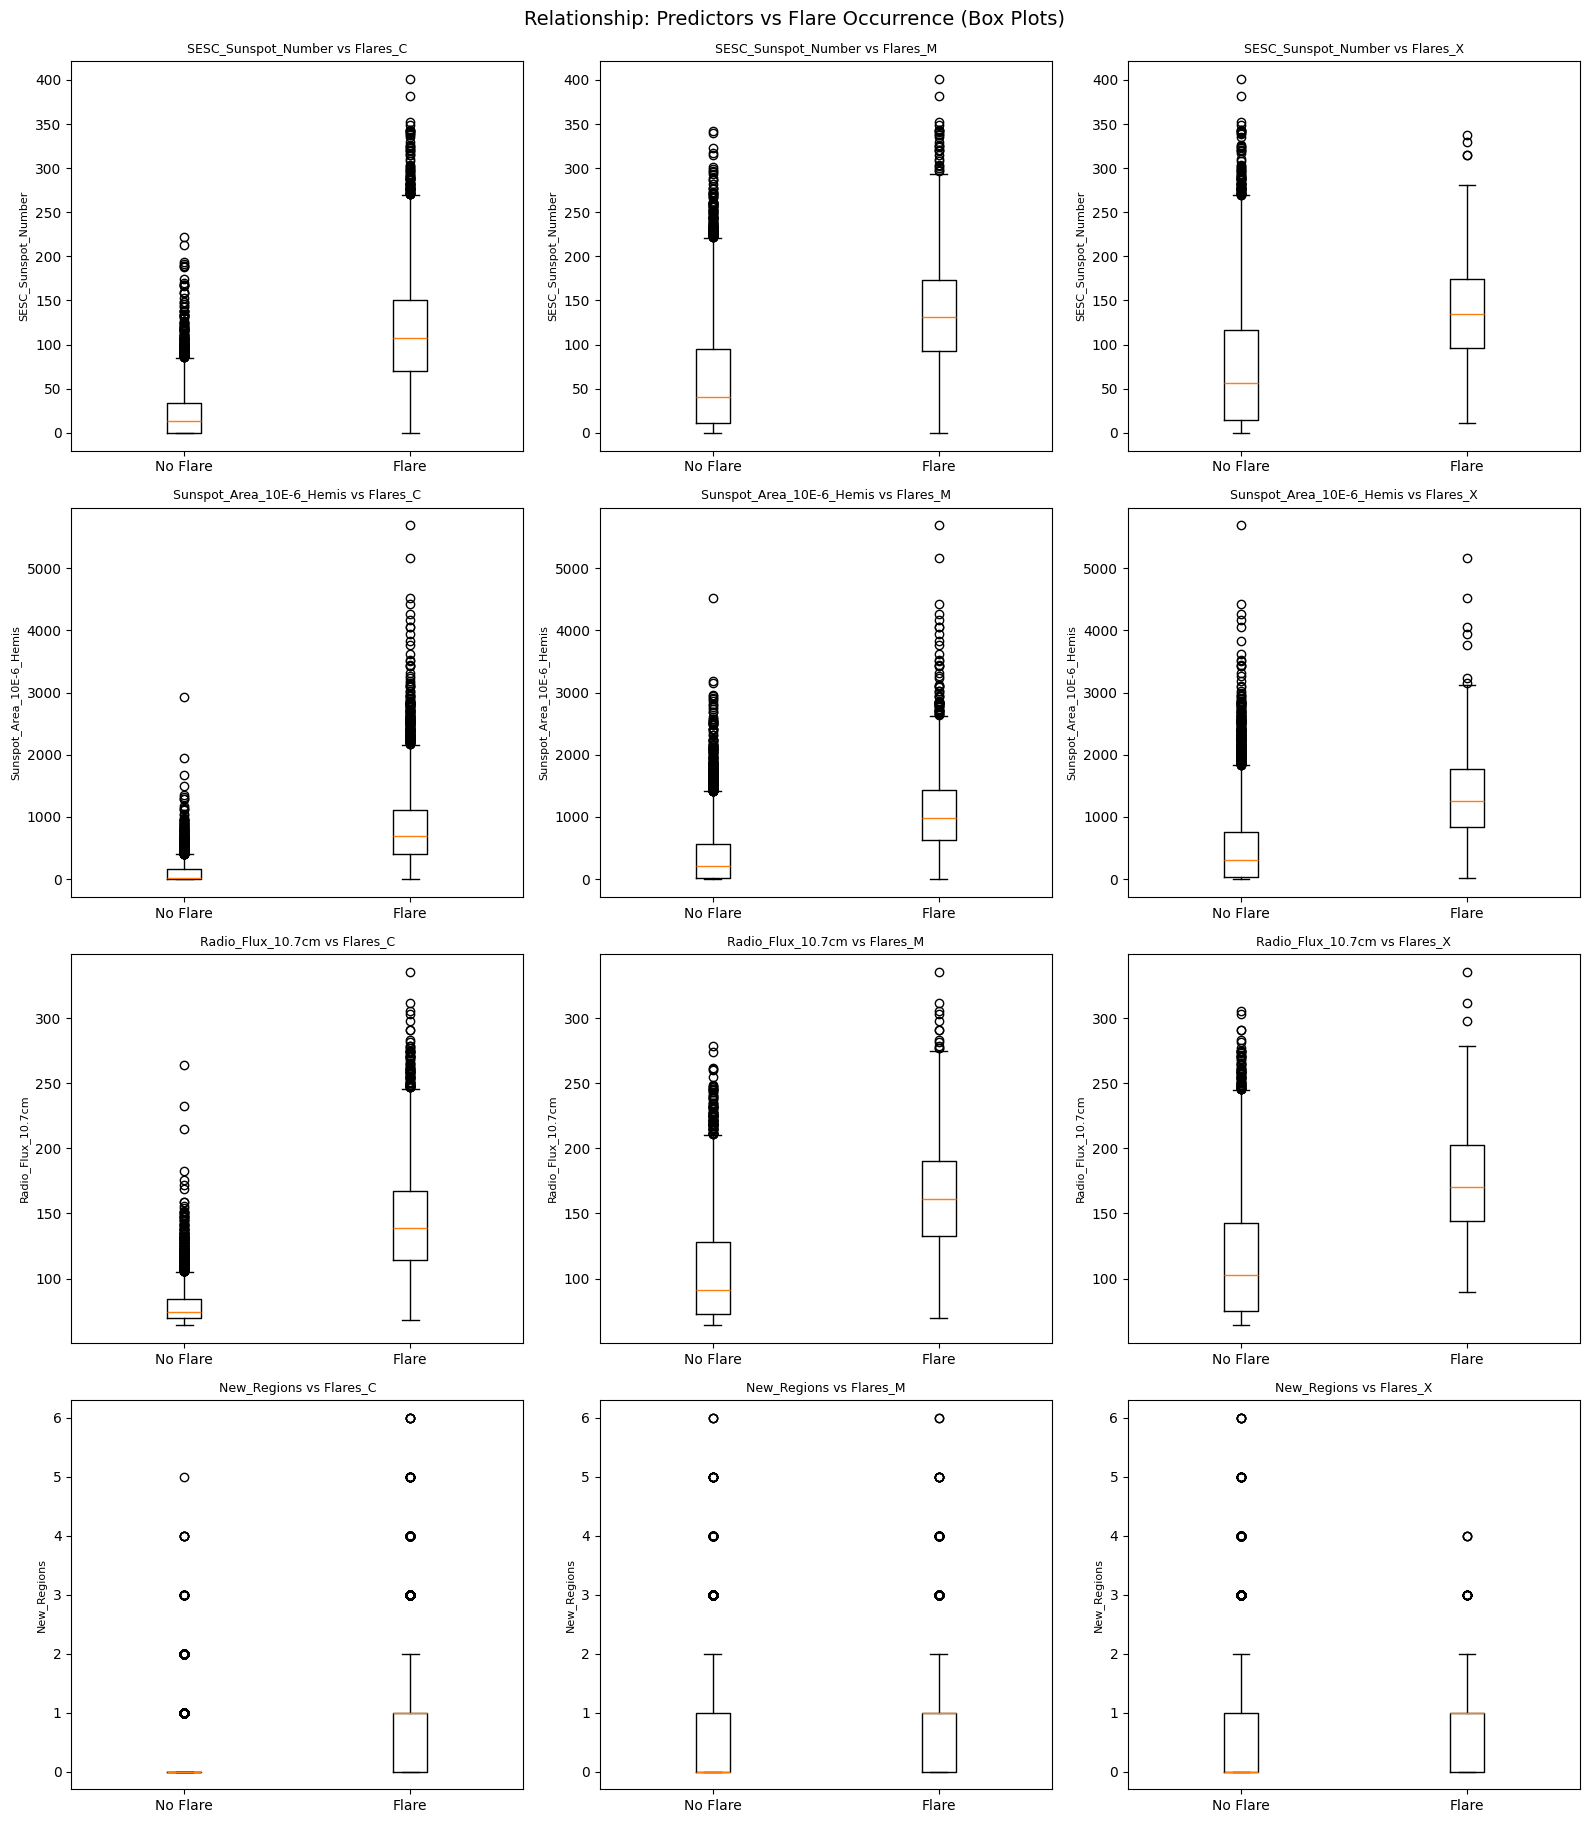

Step 5 plot saved as step5_relationship_boxplots.png


In [24]:
# predictor columns 
predictors = ["SESC_Sunspot_Number", "Sunspot_Area_10E-6_Hemis",
              "Radio_Flux_10.7cm", "New_Regions"]
 
# flare columns 
flare_types = ["Flares_C", "Flares_M", "Flares_X"]
 
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
 
for i, pred in enumerate(predictors):
    for j, flare in enumerate(flare_types):
        # flare count ko binary group banaya: 0 = no flare, 1 = flare occurred
        group = (df[flare] > 0).astype(int)
 
        # group 0 aur group 1 ke predictor values alag-alag nikal ke box plot banaya
        data_to_plot = [df[pred][group == 0], df[pred][group == 1]]
 
        axes[i, j].boxplot(data_to_plot, tick_labels=["No Flare", "Flare"])
        axes[i, j].set_title(f"{pred} vs {flare}", fontsize=9)
        axes[i, j].set_ylabel(pred, fontsize=8)
 
plt.tight_layout()
plt.suptitle("Relationship: Predictors vs Flare Occurrence (Box Plots)", y=1.01, fontsize=14)
plt.savefig("step5_relationship_boxplots.png", bbox_inches="tight")
plt.show()
 
print("Step 5 plot saved as step5_relationship_boxplots.png")
 

# 6. correlation 

In [25]:
import seaborn as sns

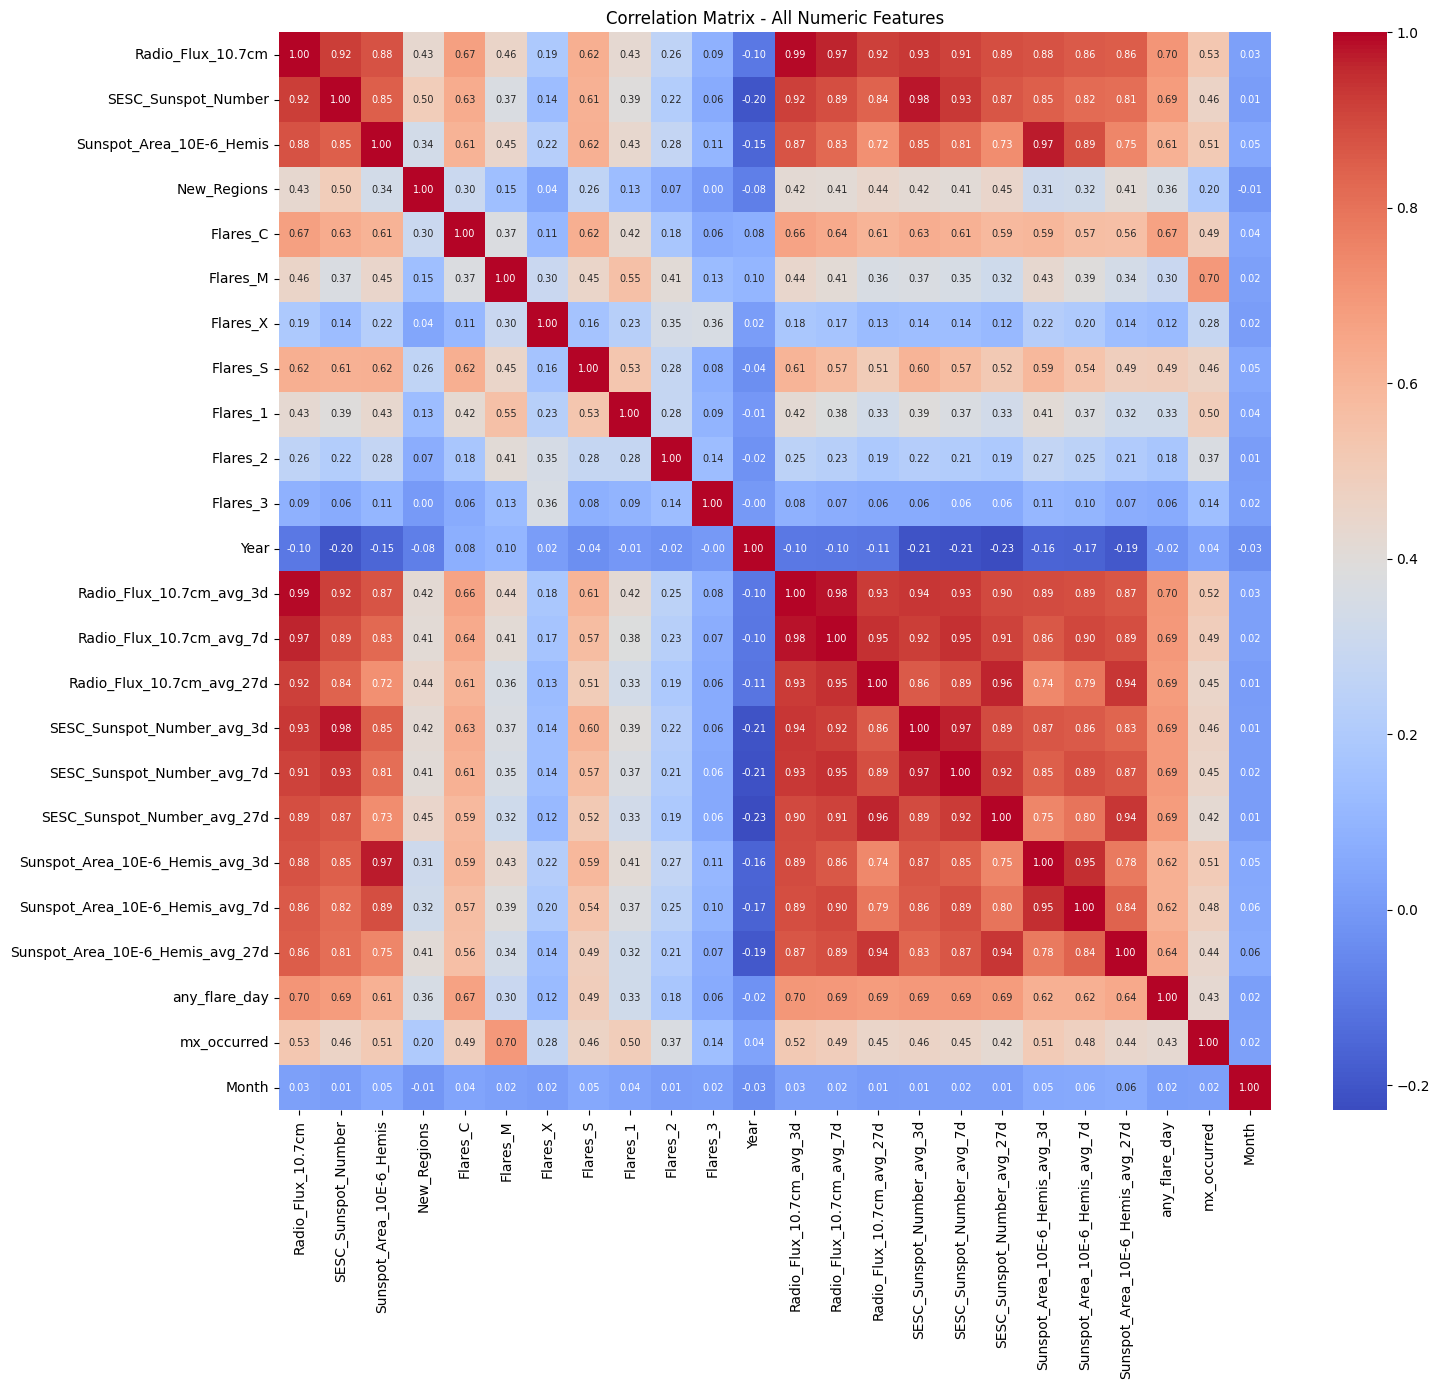

Correlation of features with Flares_C:
Flares_C                            1.000000
Radio_Flux_10.7cm                   0.669464
any_flare_day                       0.665531
Radio_Flux_10.7cm_avg_3d            0.660067
Radio_Flux_10.7cm_avg_7d            0.637092
SESC_Sunspot_Number                 0.631085
SESC_Sunspot_Number_avg_3d          0.630356
Flares_S                            0.621097
SESC_Sunspot_Number_avg_7d          0.612417
Sunspot_Area_10E-6_Hemis            0.607432
Radio_Flux_10.7cm_avg_27d           0.605990
Sunspot_Area_10E-6_Hemis_avg_3d     0.594132
SESC_Sunspot_Number_avg_27d         0.586303
Sunspot_Area_10E-6_Hemis_avg_7d     0.567861
Sunspot_Area_10E-6_Hemis_avg_27d    0.559495
mx_occurred                         0.490289
Flares_1                            0.422357
Flares_M                            0.373798
New_Regions                         0.302470
Flares_2                            0.175912
Flares_X                            0.112589
Year            

In [26]:
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            annot_kws={"size": 7}, cbar=True)
plt.title("Correlation Matrix - All Numeric Features")
plt.show()
print("Correlation of features with Flares_C:")
print(correlation_matrix["Flares_C"].sort_values(ascending=False))
print() 
print("Correlation of features with Flares_M:")
print(correlation_matrix["Flares_M"].sort_values(ascending=False))
print()
print("Correlation of features with Flares_X:")
print(correlation_matrix["Flares_X"].sort_values(ascending=False))
 

# 7. Analyze flare persistence

In [27]:
# Investigate whether flare activity today is associated with
# flare activity 
# temporary copy 
df_temp = df.copy()
# "tomorrow" ka flare status banane ke liye, M aur X count ko 1 din PEECHE
# shift karte hain (shift(-1)) - taaki current row mein "tomorrow's" value aa jaye
df_temp["Flares_M_tomorrow"] = df_temp["Flares_M"].shift(-1)
df_temp["Flares_X_tomorrow"] = df_temp["Flares_X"].shift(-1)
 
# last row ke liye "tomorrow" available nahi hai (dataset khatam ho gaya),
# isliye us row ko is analysis ke liye hata dete hain
df_temp = df_temp.dropna(subset=["Flares_M_tomorrow", "Flares_X_tomorrow"])
 
# aaj ka M/X status aur kal (tomorrow) ka M/X status - dono binary bana rahe hain
df_temp["mx_today"] = ((df_temp["Flares_M"] + df_temp["Flares_X"]) > 0).astype(int)
df_temp["mx_tomorrow"] = ((df_temp["Flares_M_tomorrow"] + df_temp["Flares_X_tomorrow"]) > 0).astype(int)
 

Chance of M/X flare TOMORROW, based on whether M/X happened TODAY:
No M/X Today    10.236511
M/X Today       57.414058
Name: mx_tomorrow, dtype: float64



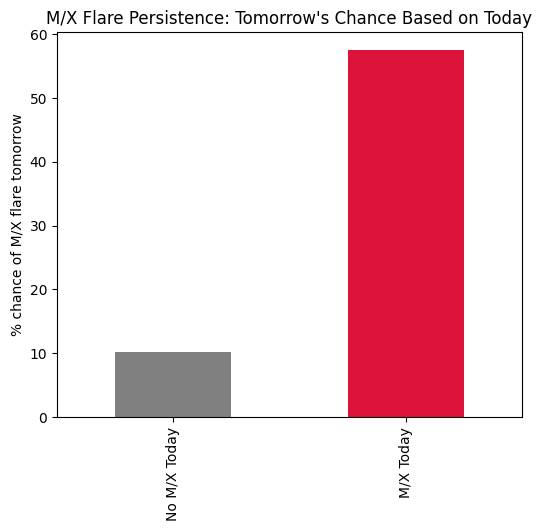

In [28]:
# "Agar AAJ M/X tha, toh KAL (tomorrow) M/X hone ka % kitna hai"
# vs "Agar aaj M/X nahi tha, toh kal kitna %"
# ---------------------------------------------------------------
persistence_table = df_temp.groupby("mx_today")["mx_tomorrow"].mean() * 100
persistence_table.index = ["No M/X Today", "M/X Today"]
 
print("Chance of M/X flare TOMORROW, based on whether M/X happened TODAY:")
print(persistence_table)
print()
 
plt.figure(figsize=(6, 5))
persistence_table.plot(kind="bar", color=["gray", "crimson"])
plt.title("M/X Flare Persistence: Tomorrow's Chance Based on Today")
plt.ylabel("% chance of M/X flare tomorrow")
plt.show()

Chance of M/X flare TOMORROW, based on whether ANY flare happened TODAY:
No Flare Today      0.916590
Any Flare Today    33.491145
Name: mx_tomorrow, dtype: float64



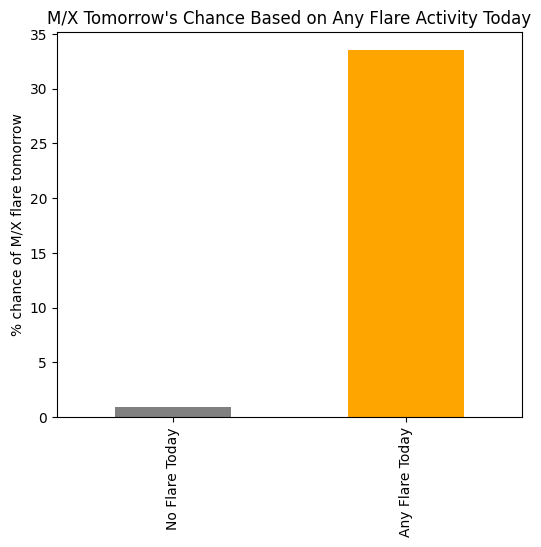

In [29]:
# ---------------------------------------------------------------
# 7.2 General flare activity persistence (not just M/X, but any flare)
# "Agar aaj koi bhi flare (C/M/X) tha, toh kal M/X ka chance kitna hai"
# ---------------------------------------------------------------
df_temp["any_flare_today"] = ((df_temp["Flares_C"] + df_temp["Flares_M"] + df_temp["Flares_X"]) > 0).astype(int)
 
general_persistence = df_temp.groupby("any_flare_today")["mx_tomorrow"].mean() * 100
general_persistence.index = ["No Flare Today", "Any Flare Today"]
 
print("Chance of M/X flare TOMORROW, based on whether ANY flare happened TODAY:")
print(general_persistence)
print()
 
plt.figure(figsize=(6, 5))
general_persistence.plot(kind="bar", color=["gray", "orange"])
plt.title("M/X Tomorrow's Chance Based on Any Flare Activity Today")
plt.ylabel("% chance of M/X flare tomorrow")
plt.show()

In [30]:
!pip install statsmodels --quiet

In [31]:
from statsmodels.graphics.tsaplots import plot_acf

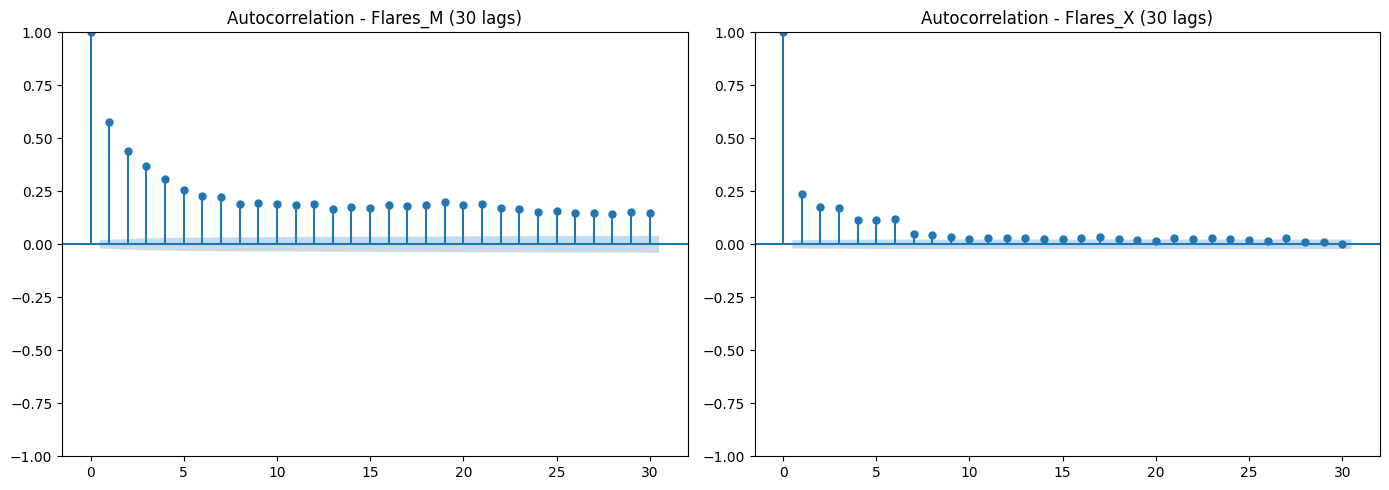

In [32]:
# ---------------------------------------------------------------
# 7.3 ACF (Autocorrelation) plot - Flares_M aur Flares_X, ~30 lags
# ye dikhata hai ki flare activity kitne din tak apne aap se
# correlated rehti hai (statistically flare persistence ka proof)
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
plot_acf(df["Flares_M"], lags=30, ax=axes[0])
axes[0].set_title("Autocorrelation - Flares_M (30 lags)")
 
plot_acf(df["Flares_X"], lags=30, ax=axes[1])
axes[1].set_title("Autocorrelation - Flares_X (30 lags)")
 
plt.tight_layout()
plt.show()

# 8.class imbalance

Class counts (0 = No M/X tomorrow, 1 = M/X tomorrow):
mx_tomorrow
0    8117
1    1950
Name: count, dtype: int64

Class percentage:
mx_tomorrow
0    80.62978
1    19.37022
Name: proportion, dtype: float64



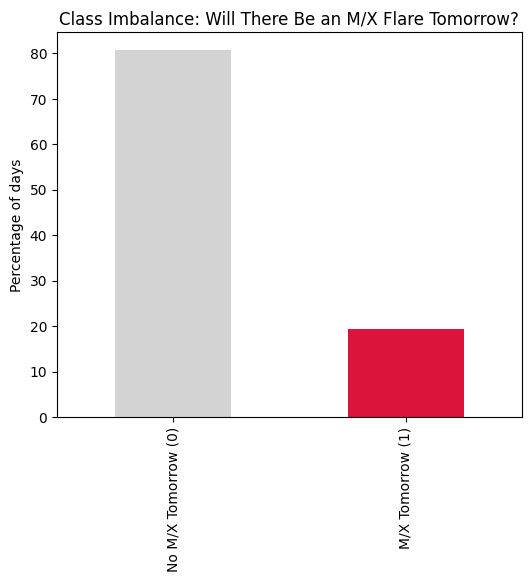


Positive class (M/X flare tomorrow) makes up only 19.37% of the data - this confirms significant class imbalance for the Stage 1 problem.


In [35]:
# Identify Class Imbalance
# 0 -> No M/X flare, 1 -> M/X flare
target_counts = df_temp["mx_tomorrow"].value_counts()
target_pct = df_temp["mx_tomorrow"].value_counts(normalize=True) * 100
 
print("Class counts (0 = No M/X tomorrow, 1 = M/X tomorrow):")
print(target_counts)
print()
 
print("Class percentage:")
print(target_pct)
print()
 
plt.figure(figsize=(6, 5))
target_pct.index = ["No M/X Tomorrow (0)", "M/X Tomorrow (1)"]
target_pct.plot(kind="bar", color=["lightgray", "crimson"])
plt.title("Class Imbalance: Will There Be an M/X Flare Tomorrow?")
plt.ylabel("Percentage of days")
plt.show()
 
print(f"\nPositive class (M/X flare tomorrow) makes up only "
      f"{target_pct['M/X Tomorrow (1)']:.2f}% of the data - this confirms "
      f"significant class imbalance for the Stage 1 problem.")
 

# 9.EDA Summary

In [37]:
print("=" * 70)
print("SOLAR FLARE PREDICTION - EDA INSIGHTS SUMMARY")
print("=" * 70)
 
# ---------------------------------------------------------------
# 1. Dataset Overview
# ---------------------------------------------------------------
print(f"\n1. DATASET OVERVIEW")
print(f"   - Total days in dataset: {df.shape[0]}")
df["Date"] = pd.to_datetime(df["Date"])
print(f"   - Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"   - Total features: {df.shape[1]}")
 
# ---------------------------------------------------------------
# 2. Flare Frequency (how common is each class)
# ---------------------------------------------------------------
total_c = df["Flares_C"].sum()
total_m = df["Flares_M"].sum()
total_x = df["Flares_X"].sum()
 
print(f"\n2. FLARE FREQUENCY (Total counts over full dataset)")
print(f"   - Total C-class flares: {int(total_c)}")
print(f"   - Total M-class flares: {int(total_m)}")
print(f"   - Total X-class flares: {int(total_x)}")
print(f"   - Insight: C-class flares are far more common than M-class, "
      f"and X-class flares are the rarest of all "
      f"({int(total_x)} X-class vs {int(total_c)} C-class over "
      f"{df.shape[0]} days).")
 
# ---------------------------------------------------------------
# 3. Zero-flare vs flare days
# ---------------------------------------------------------------
df["any_flare_day"] = ((df["Flares_C"] + df["Flares_M"] + df["Flares_X"]) > 0).astype(int)
flare_day_pct = df["any_flare_day"].mean() * 100
 
print(f"\n3. FLARE VS NO-FLARE DAYS")
print(f"   - Days with at least one flare (C/M/X): {flare_day_pct:.2f}%")
print(f"   - Days with zero flares: {100 - flare_day_pct:.2f}%")
 
# ---------------------------------------------------------------
# 4. M/X occurrence (same-day) - how rare is the "significant" flare
# ---------------------------------------------------------------
df["mx_occurred"] = ((df["Flares_M"] + df["Flares_X"]) > 0).astype(int)
mx_pct = df["mx_occurred"].mean() * 100
 
print(f"\n4. M/X FLARE RARITY (same-day)")
print(f"   - Days with an M or X class flare: {mx_pct:.2f}%")
print(f"   - Insight: Significant flares (M/X) are a minority event, "
      f"confirming this is a class-imbalance problem.")
 
# ---------------------------------------------------------------
# 5. Correlation with flare activity
# (only genuine solar-activity predictors compared - excluding
#  other flare/derived columns so the insight is meaningful)
# ---------------------------------------------------------------
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()
 
# columns we don't want to treat as "predictors" for this specific check
non_predictor_cols = [
    "Flares_C", "Flares_M", "Flares_X", "Flares_S", "Flares_1", "Flares_2", "Flares_3",
    "any_flare_day", "mx_occurred", "Year",
]
 
predictor_cols = [c for c in numeric_df.columns if c not in non_predictor_cols]
 
top_corr_c = correlation_matrix.loc[predictor_cols, "Flares_C"].sort_values(ascending=False).head(3)
top_corr_m = correlation_matrix.loc[predictor_cols, "Flares_M"].sort_values(ascending=False).head(3)
top_corr_x = correlation_matrix.loc[predictor_cols, "Flares_X"].sort_values(ascending=False).head(3)
 
print(f"\n5. TOP CORRELATED FEATURES WITH FLARE ACTIVITY")
print(f"   - Top features correlated with Flares_C: {list(top_corr_c.index)}")
print(f"   - Top features correlated with Flares_M: {list(top_corr_m.index)}")
print(f"   - Top features correlated with Flares_X: {list(top_corr_x.index)}")
print(f"   - Insight: Radio Flux and Sunspot Number/Area consistently show "
      f"the strongest relationship with flare activity, confirming they "
      f"are valuable predictors.")
 
# ---------------------------------------------------------------
# 6. Flare Persistence (temporary calculation, not saved to CSV)
# ---------------------------------------------------------------
df_temp = df.copy()
df_temp["Flares_M_tomorrow"] = df_temp["Flares_M"].shift(-1)
df_temp["Flares_X_tomorrow"] = df_temp["Flares_X"].shift(-1)
df_temp = df_temp.dropna(subset=["Flares_M_tomorrow", "Flares_X_tomorrow"])
 
df_temp["mx_today"] = ((df_temp["Flares_M"] + df_temp["Flares_X"]) > 0).astype(int)
df_temp["mx_tomorrow"] = ((df_temp["Flares_M_tomorrow"] + df_temp["Flares_X_tomorrow"]) > 0).astype(int)
 
chance_after_mx = df_temp[df_temp["mx_today"] == 1]["mx_tomorrow"].mean() * 100
chance_after_no_mx = df_temp[df_temp["mx_today"] == 0]["mx_tomorrow"].mean() * 100
 
df_temp["any_flare_today"] = ((df_temp["Flares_C"] + df_temp["Flares_M"] + df_temp["Flares_X"]) > 0).astype(int)
chance_after_any_flare = df_temp[df_temp["any_flare_today"] == 1]["mx_tomorrow"].mean() * 100
chance_after_no_flare = df_temp[df_temp["any_flare_today"] == 0]["mx_tomorrow"].mean() * 100
 
print(f"\n6. FLARE PERSISTENCE (Today -> Tomorrow)")
print(f"   - If M/X occurred today, chance of M/X tomorrow: {chance_after_mx:.2f}%")
print(f"   - If NO M/X today, chance of M/X tomorrow: {chance_after_no_mx:.2f}%")
print(f"   - If ANY flare (even C-class) occurred today, chance of M/X tomorrow: "
      f"{chance_after_any_flare:.2f}%")
print(f"   - If NO flare at all today, chance of M/X tomorrow: {chance_after_no_flare:.2f}%")
print(f"   - Insight: Flare activity clearly persists into the next day. "
      f"M/X activity today makes M/X tomorrow about "
      f"{chance_after_mx / chance_after_no_mx:.1f}x more likely. "
      f"This strongly motivates using lag features (yesterday's flare "
      f"activity) in the feature-engineering stage.")
 
# ---------------------------------------------------------------
# 7. Class Imbalance for Stage 1 target (M/X flare tomorrow)
# ---------------------------------------------------------------
target_pct = df_temp["mx_tomorrow"].mean() * 100
 
print(f"\n7. CLASS IMBALANCE (Stage 1 target: M/X flare tomorrow)")
print(f"   - Positive class (M/X tomorrow = 1): {target_pct:.2f}%")
print(f"   - Negative class (No M/X tomorrow = 0): {100 - target_pct:.2f}%")
print(f"   - Insight: The positive class is a clear minority "
      f"(~1 in {round(100/target_pct)} days), confirming this is an "
      f"imbalanced classification problem that will need techniques "
      f"like class weighting or oversampling.")
 
# ---------------------------------------------------------------
# 8. Yearly activity range (solar cycle observation)
# ---------------------------------------------------------------
yearly_mx = df.groupby("Year").apply(
    lambda x: ((x["Flares_M"] + x["Flares_X"]) > 0).mean() * 100
)
highest_year = yearly_mx.idxmax()
lowest_year = yearly_mx.idxmin()
 
print(f"\n8. YEARLY ACTIVITY PATTERN (Solar Cycle)")
print(f"   - Year with highest M/X activity: {highest_year} "
      f"({yearly_mx[highest_year]:.2f}% of days)")
print(f"   - Year with lowest M/X activity: {lowest_year} "
      f"({yearly_mx[lowest_year]:.2f}% of days)")
print(f"   - Insight: M/X flare frequency varies significantly by year, "
      f"consistent with the sun's ~11-year activity cycle.")
 
# ---------------------------------------------------------------
# 9. Known data limitations (for transparency in documentation)
# ---------------------------------------------------------------
print(f"\n9. KNOWN DATA LIMITATIONS")
print(f"   - 'Mean_Field' and 'Bkgd_XRay_Flux' columns were excluded from "
      f"the cleaned dataset due to a substantial data gap (2019-2026) "
      f"in the original NOAA source files.")
print(f"   - Rolling averages (3/7/27-day) were created only for Radio Flux, "
      f"Sunspot Number, and Sunspot Area, as these were identified as the "
      f"highest-priority features.")
 
print("\n" + "=" * 70)
print("END OF EDA INSIGHTS SUMMARY")
print("=" * 70)
 

SOLAR FLARE PREDICTION - EDA INSIGHTS SUMMARY

1. DATASET OVERVIEW
   - Total days in dataset: 10068
   - Date range: 1999-01-27 to 2026-08-20
   - Total features: 22

2. FLARE FREQUENCY (Total counts over full dataset)
   - Total C-class flares: 31642
   - Total M-class flares: 4048
   - Total X-class flares: 264
   - Insight: C-class flares are far more common than M-class, and X-class flares are the rarest of all (264 X-class vs 31642 C-class over 10068 days).

3. FLARE VS NO-FLARE DAYS
   - Days with at least one flare (C/M/X): 56.65%
   - Days with zero flares: 43.35%

4. M/X FLARE RARITY (same-day)
   - Days with an M or X class flare: 19.37%
   - Insight: Significant flares (M/X) are a minority event, confirming this is a class-imbalance problem.

5. TOP CORRELATED FEATURES WITH FLARE ACTIVITY
   - Top features correlated with Flares_C: ['Radio_Flux_10.7cm', 'Radio_Flux_10.7cm_avg_3d', 'Radio_Flux_10.7cm_avg_7d']
   - Top features correlated with Flares_M: ['Radio_Flux_10.7cm', 

C:\Users\smile\AppData\Local\Temp\ipykernel_15012\4174926500.py:125: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly_mx = df.groupby("Year").apply(
